## Part 1: Environment Setup and Library Loading
Load essential packages for image processing, neural network construction, and result visualization.

In [108]:
# Core libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import gridspec
import cv2
from glob import glob
import random

# Deep learning frameworks
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, 
    Dropout, BatchNormalization, Activation
)
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, img_to_array, load_img
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateScheduler
)

# Model evaluation tools
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split
import seaborn as sns

# Ensure reproducibility
SEED_VALUE = 42
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)
random.seed(SEED_VALUE)

# Check system configuration
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Devices: {tf.config.list_physical_devices('GPU')}")
print(f"Available GPUs: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow Version: 2.20.0
GPU Devices: []
Available GPUs: 0


## Part 2: Dataset Loading and Preprocessing
Import images from directories, normalize pixel values, and prepare for model training.

In [109]:
# Define constants
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, CHANNELS)

# Dataset path
DATASET_PATH = 'traffic'
GREEN_DIR = os.path.join(DATASET_PATH, 'Green')
RED_DIR = os.path.join(DATASET_PATH, 'Red')

def extract_images(directory, class_label, target_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    """
    Extract and preprocess images from specified directory
    
    Parameters:
        directory: Source folder containing images
        class_label: Integer label for the class
        target_size: Tuple specifying output dimensions
    
    Returns:
        Arrays of processed images and their labels
    """
    image_list = []
    label_list = []
    
    file_paths = glob(os.path.join(directory, '*.*'))
    
    for filepath in file_paths:
        try:
            # Read image in color mode
            img_array = cv2.imread(filepath, cv2.IMREAD_COLOR)
            
            if img_array is not None:
                # Convert color space
                rgb_image = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
                
                # Resize to standard dimensions
                resized_img = cv2.resize(rgb_image, target_size, 
                                        interpolation=cv2.INTER_AREA)
                
                # Normalize to [0, 1] range
                normalized_img = resized_img.astype('float32') / 255.0
                
                image_list.append(normalized_img)
                label_list.append(class_label)
        except Exception as error:
            print(f"Failed to process {filepath}: {error}")
            continue
    
    return image_list, label_list

# Extract green traffic light images (class 0)
green_imgs, green_lbls = extract_images(GREEN_DIR, class_label=0)

# Extract red traffic light images (class 1)
red_imgs, red_lbls = extract_images(RED_DIR, class_label=1)

# Merge datasets
all_images = np.array(green_imgs + red_imgs, dtype='float32')
all_labels = np.array(green_lbls + red_lbls, dtype='int32')

print(f"Dataset Statistics:")
print(f"  Total Images: {len(all_images)}")
print(f"  Green Lights: {len(green_imgs)}")
print(f"  Red Lights: {len(red_imgs)}")
print(f"  Image Dimensions: {all_images[0].shape}")

Dataset Statistics:
  Total Images: 200
  Green Lights: 100
  Red Lights: 100
  Image Dimensions: (128, 128, 3)


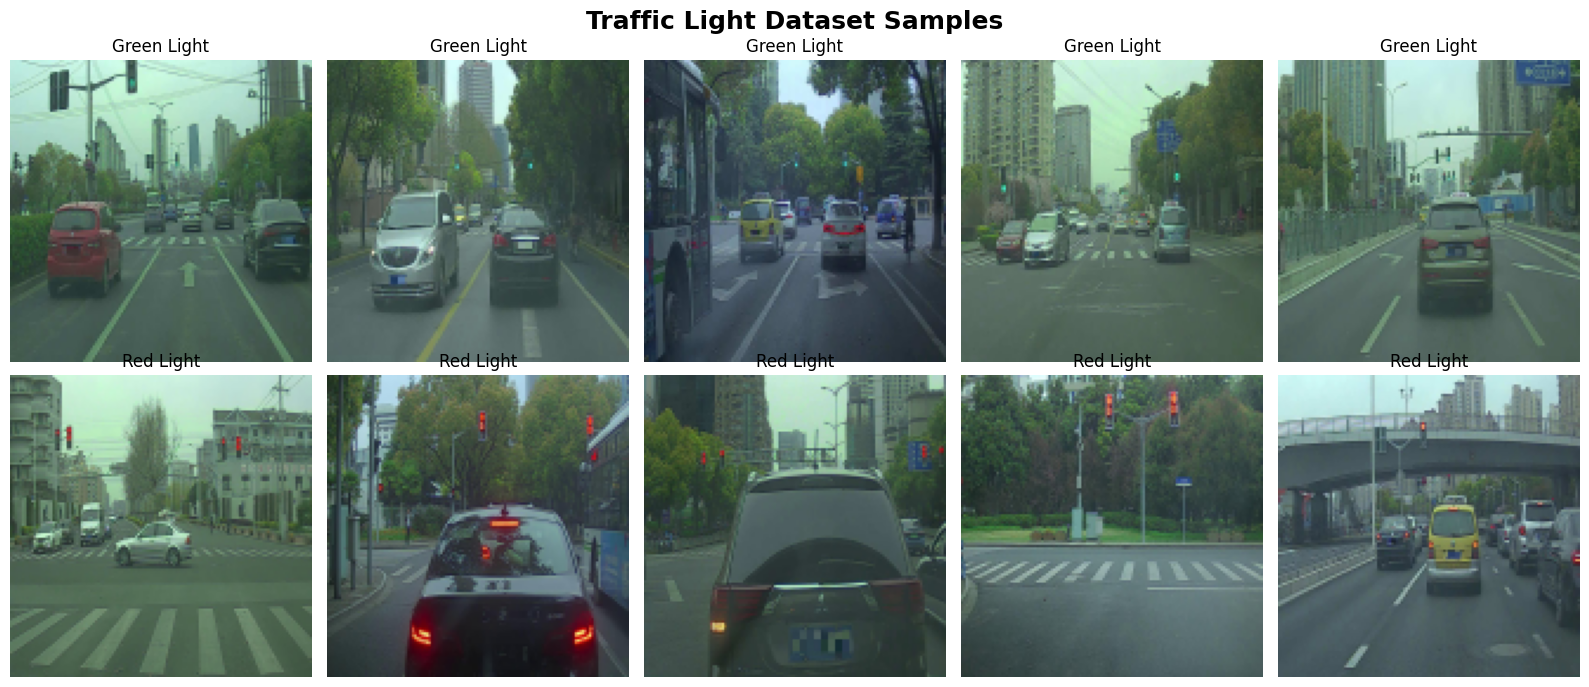

In [110]:
# Display sample images from dataset
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(2, 5, figure=fig)

fig.suptitle('Traffic Light Dataset Samples', fontsize=18, weight='bold')

# Display green samples
for idx in range(5):
    ax = fig.add_subplot(gs[0, idx])
    ax.imshow(green_imgs[idx])
    ax.set_title('Green Light', fontsize=12)
    ax.axis('off')

# Display red samples
for idx in range(5):
    ax = fig.add_subplot(gs[1, idx])
    ax.imshow(red_imgs[idx])
    ax.set_title('Red Light', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [111]:
# Partition data: 70% training, 15% validation, 15% testing
# Stage 1: Separate training set
train_images, temp_images, train_labels, temp_labels = train_test_split(
    all_images, all_labels, 
    test_size=0.30, 
    random_state=SEED_VALUE, 
    stratify=all_labels
)

# Stage 2: Split remaining into validation and test sets
val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, 
    test_size=0.50, 
    random_state=SEED_VALUE, 
    stratify=temp_labels
)

print(f"Data Partitioning Summary:")
print(f"  Training Samples: {train_images.shape[0]}")
print(f"  Validation Samples: {val_images.shape[0]}")
print(f"  Test Samples: {test_images.shape[0]}")
print(f"\nTraining Set Class Balance:")
print(f"  Green (0): {np.sum(train_labels == 0)} samples")
print(f"  Red (1): {np.sum(train_labels == 1)} samples")

Data Partitioning Summary:
  Training Samples: 140
  Validation Samples: 30
  Test Samples: 30

Training Set Class Balance:
  Green (0): 70 samples
  Red (1): 70 samples


In [112]:
# Configure data augmentation pipeline
# Apply random transformations to increase dataset diversity
augmentation_config = ImageDataGenerator(
    rotation_range=15,           # Rotate images up to 15 degrees
    width_shift_range=0.1,       # Horizontal translation
    height_shift_range=0.1,      # Vertical translation
    shear_range=0.1,             # Shear transformation
    zoom_range=0.2,              # Zoom in/out
    horizontal_flip=True,        # Mirror images horizontally
    fill_mode='nearest'          # Strategy for filling new pixels
)

# Fit augmentation pipeline to training data
augmentation_config.fit(train_images)

print("Data Augmentation Pipeline Configured")
print("Transformations Applied:")
print("  - Random Rotation: ±15°")
print("  - Translation: ±10%")
print("  - Shearing: 10%")
print("  - Zoom: ±20%")
print("  - Horizontal Flip: Enabled")

Data Augmentation Pipeline Configured
Transformations Applied:
  - Random Rotation: ±15°
  - Translation: ±10%
  - Shearing: 10%
  - Zoom: ±20%
  - Horizontal Flip: Enabled


## Part 3: Baseline CNN Architecture
Construct a sequential convolutional neural network with 3 convolutional blocks for feature extraction.

In [113]:
def construct_baseline_cnn(img_shape=INPUT_SHAPE):
    """
    Build a baseline CNN architecture for binary classification
    
    Architecture Design:
    - Three convolutional blocks with increasing filter counts
    - MaxPooling for spatial dimension reduction
    - Fully connected layers with dropout regularization
    - Sigmoid activation for binary output
    """
    # Define input layer
    input_layer = Input(shape=img_shape, name='input')
    
    # First convolutional block (32 filters)
    conv1 = Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', name='conv1')(input_layer)
    pool1 = MaxPooling2D(pool_size=(2, 2), name='pool1')(conv1)
    
    # Second convolutional block (64 filters)
    conv2 = Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', name='conv2')(pool1)
    pool2 = MaxPooling2D(pool_size=(2, 2), name='pool2')(conv2)
    
    # Third convolutional block (128 filters)
    conv3 = Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', name='conv3')(pool2)
    pool3 = MaxPooling2D(pool_size=(2, 2), name='pool3')(conv3)
    
    # Flatten feature maps
    flat = Flatten(name='flatten')(pool3)
    
    # Dense classification layers
    dense1 = Dense(128, activation='relu', name='dense1')(flat)
    dropout1 = Dropout(0.5, name='dropout1')(dense1)
    
    # Output layer for binary classification
    output_layer = Dense(1, activation='sigmoid', name='output')(dropout1)
    
    # Create model
    baseline_model = Model(inputs=input_layer, outputs=output_layer, name='baseline_cnn')
    
    return baseline_model

# Instantiate baseline model
baseline_cnn = construct_baseline_cnn()

# Configure optimizer and loss function
baseline_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display architecture
baseline_cnn.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

## Part 4: Model Training and Performance Evaluation
Train the baseline model with early stopping and evaluate performance metrics.

In [114]:
# Configure training callbacks
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

# Training configuration
NUM_EPOCHS = 20
BATCH_SIZE_TRAIN = 32

print("Initiating Model Training...\n")

# Train with augmented data
training_history = baseline_cnn.fit(
    augmentation_config.flow(train_images, train_labels, batch_size=BATCH_SIZE_TRAIN),
    validation_data=(val_images, val_labels),
    epochs=NUM_EPOCHS,
    callbacks=[early_stop_callback],
    verbose=1
)

print("\nTraining Process Completed!")

Initiating Model Training...

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.4500 - loss: 0.7259 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.5643 - loss: 0.6900 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.5143 - loss: 0.6952 - val_accuracy: 0.5000 - val_loss: 0.6920
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 0.4571 - loss: 0.7005 - val_accuracy: 0.5000 - val_loss: 0.6909
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.5286 - loss: 0.6908 - val_accuracy: 0.5000 - val_loss: 0.6898
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.5214 - loss: 0.6879 - val_accuracy: 0.5000 - val_loss: 0.6827
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.5571 - loss: 0.6712 - val_accuracy: 0.5000 - val_loss: 0.6811
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - accuracy: 0.5286 - loss: 0.6429 - va

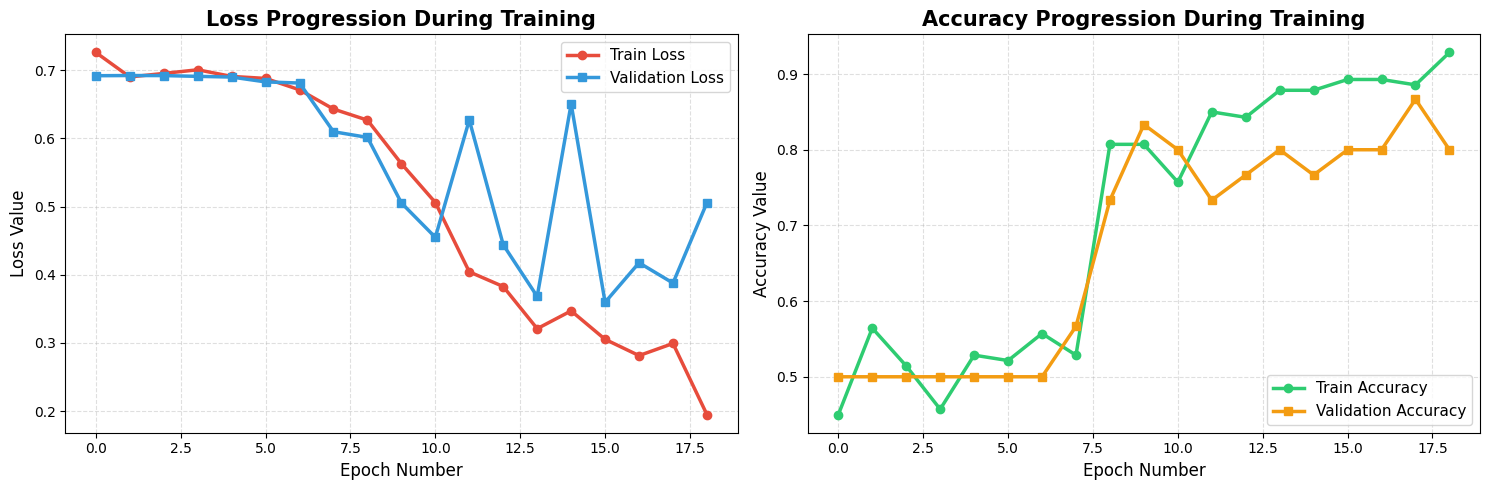

In [115]:
# Visualize training progression
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1.plot(training_history.history['loss'], marker='o', label='Train Loss', linewidth=2.5, color='#e74c3c')
ax1.plot(training_history.history['val_loss'], marker='s', label='Validation Loss', linewidth=2.5, color='#3498db')
ax1.set_title('Loss Progression During Training', fontsize=15, weight='bold')
ax1.set_xlabel('Epoch Number', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.4)

# Accuracy curves
ax2.plot(training_history.history['accuracy'], marker='o', label='Train Accuracy', linewidth=2.5, color='#2ecc71')
ax2.plot(training_history.history['val_accuracy'], marker='s', label='Validation Accuracy', linewidth=2.5, color='#f39c12')
ax2.set_title('Accuracy Progression During Training', fontsize=15, weight='bold')
ax2.set_xlabel('Epoch Number', fontsize=12)
ax2.set_ylabel('Accuracy Value', fontsize=12)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [116]:
# Evaluate baseline model on test dataset
print("Evaluating Baseline Model Performance...\n")

baseline_loss, baseline_acc = baseline_cnn.evaluate(test_images, test_labels, verbose=0)

print(f"Test Results:")
print(f"  Loss: {baseline_loss:.4f}")
print(f"  Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")

# Generate predictions
baseline_predictions_prob = baseline_cnn.predict(test_images, verbose=0)
baseline_predictions = (baseline_predictions_prob > 0.5).astype('int32').reshape(-1)

# Detailed classification metrics
print("\nDetailed Classification Report:")
print(classification_report(test_labels, baseline_predictions, 
                          target_names=['Green Light', 'Red Light'], 
                          digits=4))

Evaluating Baseline Model Performance...

Test Results:
  Loss: 0.6799
  Accuracy: 0.8667 (86.67%)

Detailed Classification Report:
              precision    recall  f1-score   support

 Green Light     0.8235    0.9333    0.8750        15
   Red Light     0.9231    0.8000    0.8571        15

    accuracy                         0.8667        30
   macro avg     0.8733    0.8667    0.8661        30
weighted avg     0.8733    0.8667    0.8661        30



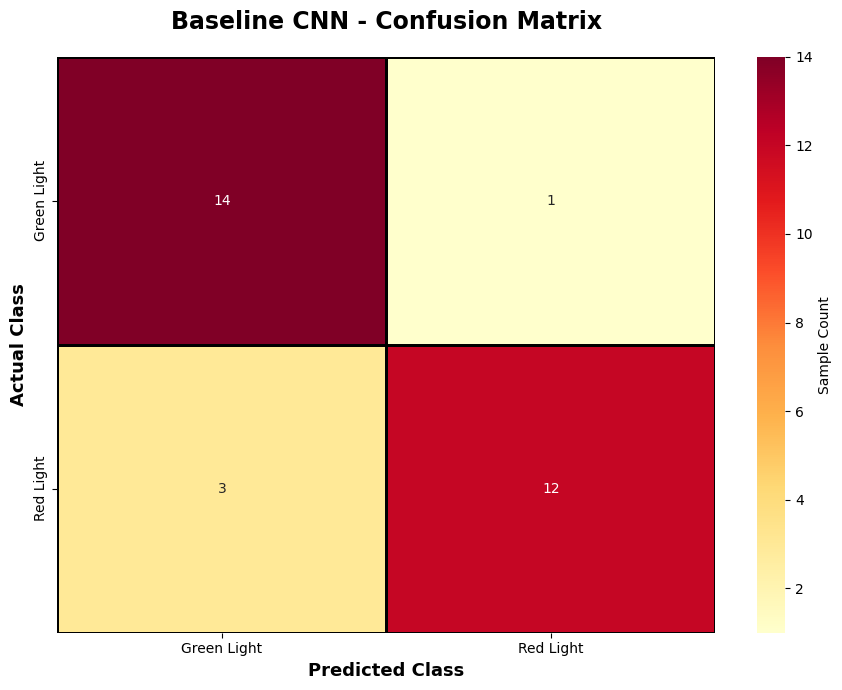


Confusion Matrix Analysis:
  True Negatives (Correct Green): 14
  False Positives (Green as Red): 1
  False Negatives (Red as Green): 3
  True Positives (Correct Red): 12


In [117]:
# Generate confusion matrix visualization
conf_matrix_baseline = confusion_matrix(test_labels, baseline_predictions)

plt.figure(figsize=(9, 7))
sns.heatmap(conf_matrix_baseline, 
            annot=True, 
            fmt='d', 
            cmap='YlOrRd', 
            xticklabels=['Green Light', 'Red Light'],
            yticklabels=['Green Light', 'Red Light'],
            cbar_kws={'label': 'Sample Count'},
            linewidths=1,
            linecolor='black')
plt.title('Baseline CNN - Confusion Matrix', fontsize=17, weight='bold', pad=20)
plt.xlabel('Predicted Class', fontsize=13, weight='bold')
plt.ylabel('Actual Class', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# Detailed confusion matrix statistics
true_neg, false_pos, false_neg, true_pos = conf_matrix_baseline.ravel()
print(f"\nConfusion Matrix Analysis:")
print(f"  True Negatives (Correct Green): {true_neg}")
print(f"  False Positives (Green as Red): {false_pos}")
print(f"  False Negatives (Red as Green): {false_neg}")
print(f"  True Positives (Correct Red): {true_pos}")

## Part 5: External Image Testing
Evaluate model performance on 5 external traffic light images.

External images directory not found.
Demonstrating with random test set samples...



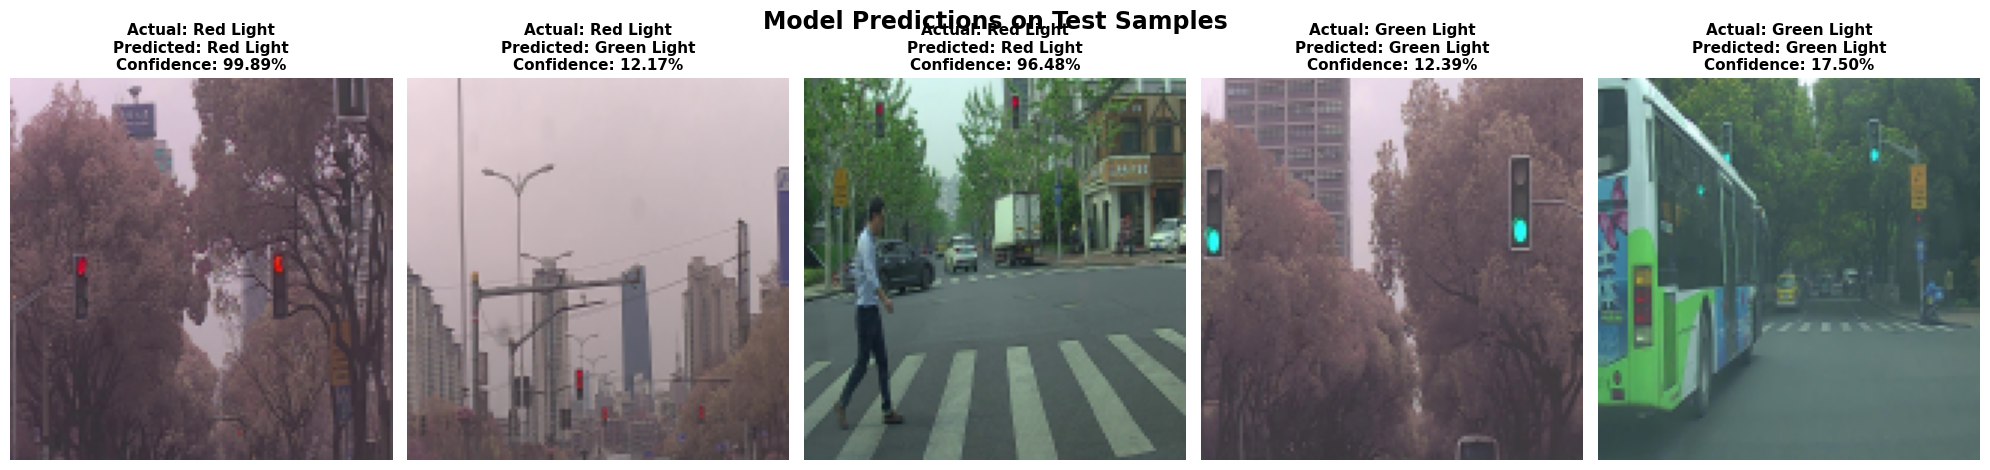

In [118]:
def process_external_image(path_to_image, target_dim=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    """
    Preprocess external image for model inference
    
    Returns original and processed versions of the image
    """
    try:
        # Load image
        raw_image = cv2.imread(path_to_image)
        if raw_image is None:
            raise ValueError(f"Cannot read image: {path_to_image}")
        
        # Convert to RGB
        rgb_img = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
        
        # Resize to model input size
        resized = cv2.resize(rgb_img, target_dim, interpolation=cv2.INTER_CUBIC)
        
        # Normalize pixel values
        normalized = resized.astype('float32') / 255.0
        
        return rgb_img, normalized
    except Exception as err:
        print(f"Error processing {path_to_image}: {err}")
        return None, None

# External image paths
external_test_paths = [
    'external_test_images/traffic1.jpg',
    'external_test_images/traffic2.jpg',
    'external_test_images/traffic3.jpg',
    'external_test_images/traffic4.jpg',
    'external_test_images/traffic5.jpg'
]

# Check if external directory exists
if not os.path.exists('external_test_images'):
    print("External images directory not found.")
    print("Demonstrating with random test set samples...\n")
    
    # Select random test samples
    sample_indices = random.sample(range(len(test_images)), 5)
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle('Model Predictions on Test Samples', fontsize=17, weight='bold')
    
    for idx, sample_idx in enumerate(sample_indices):
        test_img = test_images[sample_idx]
        actual_label = test_labels[sample_idx]
        
        # Predict
        prediction_prob = baseline_cnn.predict(np.expand_dims(test_img, axis=0), verbose=0)[0][0]
        predicted_class = 'Red Light' if prediction_prob > 0.5 else 'Green Light'
        actual_class = 'Red Light' if actual_label == 1 else 'Green Light'
        
        # Display
        axes[idx].imshow(test_img)
        axes[idx].set_title(f'Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {prediction_prob:.2%}', 
                          fontsize=11, weight='bold')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    # Process external images
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle('Predictions on External Traffic Light Images', fontsize=17, weight='bold')
    
    for idx, img_path in enumerate(external_test_paths):
        orig_img, proc_img = process_external_image(img_path)
        
        if proc_img is not None:
            # Predict
            pred_prob = baseline_cnn.predict(np.expand_dims(proc_img, axis=0), verbose=0)[0][0]
            pred_label = 'Red Light' if pred_prob > 0.5 else 'Green Light'
            
            # Display
            axes[idx].imshow(orig_img)
            axes[idx].set_title(f'Prediction: {pred_label}\nConfidence: {pred_prob:.2%}', 
                              fontsize=11, weight='bold')
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## Part 6: Performance Enhancement Techniques
Implement two distinct strategies to boost classification accuracy.

### Enhancement Strategy 1: Learning Rate Scheduling with Optimized Architecture
Implement learning rate reduction on plateau and add an extra convolutional layer for better feature extraction.

In [119]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

def construct_enhanced_cnn_lr(img_shape=INPUT_SHAPE):
    """
    Build enhanced CNN with additional convolutional layer
    
    Improvements:
    - Four convolutional blocks instead of three for better feature learning
    - Progressive filter increase (32 -> 64 -> 128 -> 256)
    - Will be trained with learning rate scheduling
    - Strategic dropout placement
    """
    # Input layer
    input_layer = Input(shape=img_shape, name='input_lr')
    
    # Block 1: 32 filters
    x = Conv2D(32, (3, 3), padding='same', activation='relu', name='conv_lr1')(input_layer)
    x = MaxPooling2D((2, 2), name='pool_lr1')(x)
    
    # Block 2: 64 filters
    x = Conv2D(64, (3, 3), padding='same', activation='relu', name='conv_lr2')(x)
    x = MaxPooling2D((2, 2), name='pool_lr2')(x)
    
    # Block 3: 128 filters
    x = Conv2D(128, (3, 3), padding='same', activation='relu', name='conv_lr3')(x)
    x = MaxPooling2D((2, 2), name='pool_lr3')(x)
    
    # Block 4: 256 filters (additional layer)
    x = Conv2D(256, (3, 3), padding='same', activation='relu', name='conv_lr4')(x)
    x = MaxPooling2D((2, 2), name='pool_lr4')(x)
    
    # Flatten and classify
    x = Flatten(name='flatten_lr')(x)
    x = Dense(256, activation='relu', name='dense1_lr')(x)
    x = Dropout(0.5, name='dropout1_lr')(x)
    x = Dense(128, activation='relu', name='dense2_lr')(x)
    x = Dropout(0.3, name='dropout2_lr')(x)
    
    # Output
    output_layer = Dense(1, activation='sigmoid', name='output_lr')(x)
    
    enhanced_model = Model(inputs=input_layer, outputs=output_layer, name='enhanced_cnn_lr')
    
    return enhanced_model

# Build enhanced model
print("Constructing Enhanced CNN with Learning Rate Scheduling...\n")
enhanced_lr_model = construct_enhanced_cnn_lr()

# Compile with optimizer
enhanced_lr_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display architecture
enhanced_lr_model.summary()

Constructing Enhanced CNN with Learning Rate Scheduling...



Model: "enhanced_cnn_lr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_lr (InputLayer)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lr1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_lr1 (MaxPooling2D)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lr2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_lr2 (MaxPooling2D)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lr3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_lr3 (MaxPooling2D)         │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lr4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_lr4 (MaxPooling2D)         │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_lr (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1_lr (Dense)               │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1_lr (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2_lr (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2_lr (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_lr (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,616,001 (17.61 MB)

 Trainable params: 4,616,001 (17.61 MB)

 Non-trainable params: 0 (0.00 B)

In [120]:
# Train enhanced model with learning rate scheduling
print("Training Enhanced Model (Learning Rate Scheduling)...\n")

# Callbacks
early_stop_lr = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Training
history_enhanced_lr = enhanced_lr_model.fit(

    augmentation_config.flow(train_images, train_labels, batch_size=BATCH_SIZE_TRAIN),
    
    validation_data=(val_images, val_labels),

    epochs=20,

    callbacks=[early_stop_lr, reduce_lr],
    verbose=1
)
print("\nEnhanced Model Training Completed!")


Training Enhanced Model (Learning Rate Scheduling)...

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 354ms/step - accuracy: 0.4286 - loss: 0.7188 - val_accuracy: 0.5000 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 0.5143 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.4786 - loss: 0.6962 - val_accuracy: 0.5000 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.4857 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.5071 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6911 - learning_rate: 0.0010
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - accuracy: 0.5000 - loss: 0.6864 - val_accuracy: 0.5000 - val_loss: 0.6880 - learning_rate: 0.0010
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/

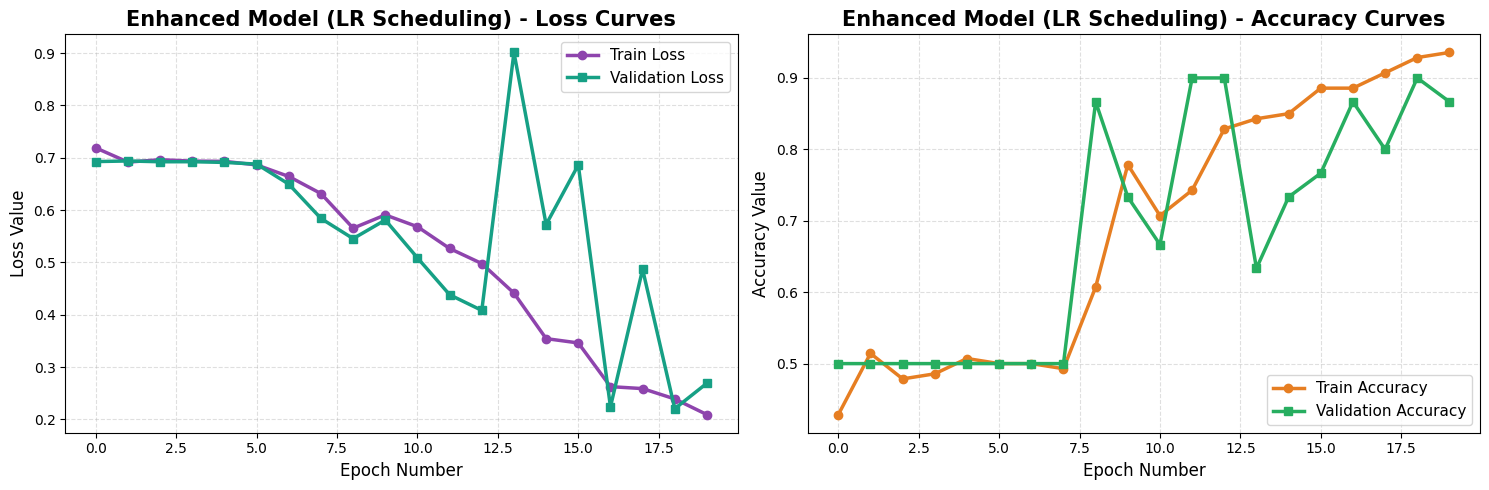

In [121]:
# Visualize enhanced model training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss visualization
ax1.plot(history_enhanced_lr.history['loss'], marker='o', label='Train Loss', linewidth=2.5, color='#8e44ad')
ax1.plot(history_enhanced_lr.history['val_loss'], marker='s', label='Validation Loss', linewidth=2.5, color='#16a085')
ax1.set_title('Enhanced Model (LR Scheduling) - Loss Curves', fontsize=15, weight='bold')
ax1.set_xlabel('Epoch Number', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.4)

# Accuracy visualization
ax2.plot(history_enhanced_lr.history['accuracy'], marker='o', label='Train Accuracy', linewidth=2.5, color='#e67e22')
ax2.plot(history_enhanced_lr.history['val_accuracy'], marker='s', label='Validation Accuracy', linewidth=2.5, color='#27ae60')
ax2.set_title('Enhanced Model (LR Scheduling) - Accuracy Curves', fontsize=15, weight='bold')
ax2.set_xlabel('Epoch Number', fontsize=12)
ax2.set_ylabel('Accuracy Value', fontsize=12)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [122]:
# Evaluate enhanced LR model
print("Evaluating Enhanced Model (Learning Rate Scheduling)...\n")

lr_loss, lr_acc = enhanced_lr_model.evaluate(test_images, test_labels, verbose=0)

print(f"Enhanced Model (LR Scheduling) Test Results:")
print(f"  Loss: {lr_loss:.4f}")
print(f"  Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")

# Predictions
lr_predictions_prob = enhanced_lr_model.predict(test_images, verbose=0)
lr_predictions = (lr_predictions_prob > 0.5).astype('int32').reshape(-1)

# Classification report
print("\nClassification Metrics:")
print(classification_report(test_labels, lr_predictions, 
                          target_names=['Green Light', 'Red Light'],
                          digits=4))

Evaluating Enhanced Model (Learning Rate Scheduling)...

Enhanced Model (LR Scheduling) Test Results:
  Loss: 0.3244
  Accuracy: 0.9000 (90.00%)

Classification Metrics:
              precision    recall  f1-score   support

 Green Light     1.0000    0.8000    0.8889        15
   Red Light     0.8333    1.0000    0.9091        15

    accuracy                         0.9000        30
   macro avg     0.9167    0.9000    0.8990        30
weighted avg     0.9167    0.9000    0.8990        30



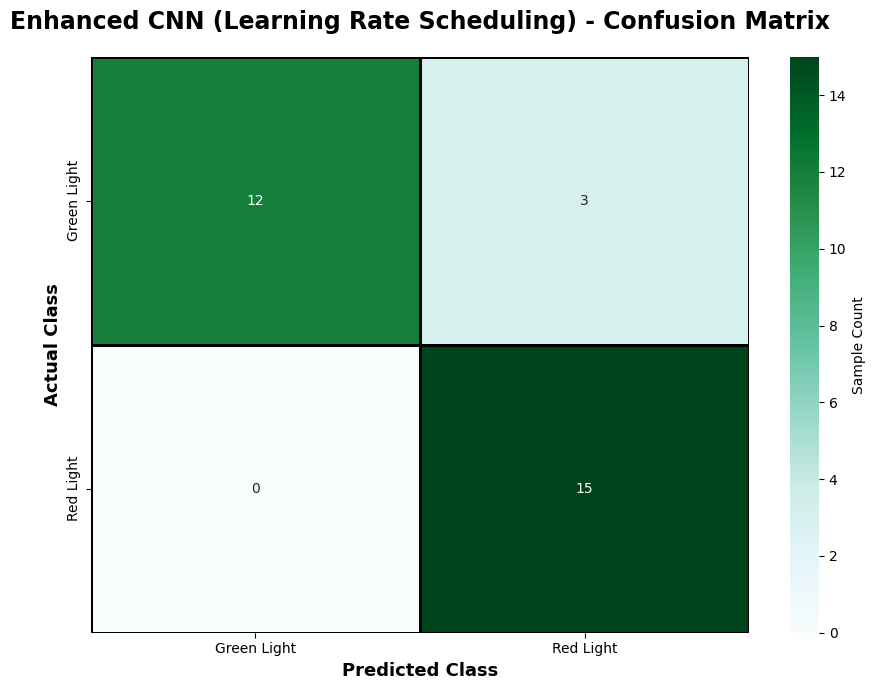

In [123]:
# Confusion matrix for enhanced LR model
conf_matrix_lr = confusion_matrix(test_labels, lr_predictions)

plt.figure(figsize=(9, 7))
sns.heatmap(conf_matrix_lr, 
            annot=True, 
            fmt='d', 
            cmap='BuGn', 
            xticklabels=['Green Light', 'Red Light'],
            yticklabels=['Green Light', 'Red Light'],
            cbar_kws={'label': 'Sample Count'},
            linewidths=1,
            linecolor='black')
plt.title('Enhanced CNN (Learning Rate Scheduling) - Confusion Matrix', 
         fontsize=17, weight='bold', pad=20)
plt.xlabel('Predicted Class', fontsize=13, weight='bold')
plt.ylabel('Actual Class', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

### Enhancement Strategy 2: SGD Optimizer with Momentum and Nesterov
Use SGD optimizer with momentum and Nesterov acceleration for better convergence and generalization.

In [124]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import SpatialDropout2D

def construct_sgd_cnn(img_shape=INPUT_SHAPE):
    """
    Build CNN optimized for SGD training with Spatial Dropout
    
    Improvements:
    - Spatial Dropout instead of regular dropout in conv layers
    - Will use SGD with momentum and Nesterov acceleration
    - Batch Normalization for stable training with SGD
    - Same 3-layer architecture as baseline for fair comparison
    """
    input_layer = Input(shape=img_shape, name='input_sgd')
    
    # Block 1
    x = Conv2D(32, (3, 3), padding='same', name='conv_sgd1')(input_layer)
    x = BatchNormalization(name='bn_sgd1')(x)
    x = Activation('relu', name='relu_sgd1')(x)
    x = MaxPooling2D((2, 2), name='pool_sgd1')(x)
    x = SpatialDropout2D(0.2, name='spatial_drop1')(x)
    
    # Block 2
    x = Conv2D(64, (3, 3), padding='same', name='conv_sgd2')(x)
    x = BatchNormalization(name='bn_sgd2')(x)
    x = Activation('relu', name='relu_sgd2')(x)
    x = MaxPooling2D((2, 2), name='pool_sgd2')(x)
    x = SpatialDropout2D(0.2, name='spatial_drop2')(x)
    
    # Block 3
    x = Conv2D(128, (3, 3), padding='same', name='conv_sgd3')(x)
    x = BatchNormalization(name='bn_sgd3')(x)
    x = Activation('relu', name='relu_sgd3')(x)
    x = MaxPooling2D((2, 2), name='pool_sgd3')(x)
    
    # Dense layers
    x = Flatten(name='flatten_sgd')(x)
    x = Dense(128, name='dense_sgd')(x)
    x = BatchNormalization(name='bn_dense_sgd')(x)
    x = Activation('relu', name='relu_dense_sgd')(x)
    x = Dropout(0.5, name='dropout_sgd')(x)
    
    output_layer = Dense(1, activation='sigmoid', name='output_sgd')(x)
    
    sgd_model = Model(inputs=input_layer, outputs=output_layer, name='sgd_cnn')
    return sgd_model

print("Constructing Model for SGD Optimizer Training...\n")
sgd_model = construct_sgd_cnn()

# Compile with SGD optimizer (momentum + Nesterov)
sgd_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

sgd_model.summary()

Constructing Model for SGD Optimizer Training...



Model: "sgd_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sgd (InputLayer)          │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_sgd1 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_sgd1 (BatchNormalization)    │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_sgd1 (Activation)          │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_sgd1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_drop1                   │ (None, 64, 64, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_sgd2 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_sgd2 (BatchNormalization)    │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_sgd2 (Activation)          │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_sgd2 (MaxPooling2D)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_drop2                   │ (None, 32, 32, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_sgd3 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_sgd3 (BatchNormalization)    │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_sgd3 (Activation)          │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_sgd3 (MaxPooling2D)        │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_sgd (Flatten)           │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_sgd (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_sgd                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_sgd (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_sgd (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_sgd (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,217 (16.36 MB)

 Trainable params: 4,288,513 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [125]:
# Train with SGD optimizer
print("Training with SGD Optimizer (Momentum + Nesterov)...\n")

early_stop_sgd = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_sgd = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_sgd = sgd_model.fit(
    augmentation_config.flow(train_images, train_labels, batch_size=BATCH_SIZE_TRAIN),
    validation_data=(val_images, val_labels),
    epochs=20,
    callbacks=[early_stop_sgd, reduce_lr_sgd],
    verbose=1
)

print("\nSGD Model Training Completed!")

Training with SGD Optimizer (Momentum + Nesterov)...

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 477ms/step - accuracy: 0.4571 - loss: 0.9959 - val_accuracy: 0.5000 - val_loss: 0.6953 - learning_rate: 0.0100
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 400ms/step - accuracy: 0.6286 - loss: 0.7357 - val_accuracy: 0.5333 - val_loss: 0.6874 - learning_rate: 0.0100
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 404ms/step - accuracy: 0.6500 - loss: 0.6580 - val_accuracy: 0.5667 - val_loss: 0.6773 - learning_rate: 0.0100
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step - accuracy: 0.7000 - loss: 0.6404 - val_accuracy: 0.6667 - val_loss: 0.6691 - learning_rate: 0.0100
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 389ms/step - accuracy: 0.7500 - loss: 0.5137 - val_accuracy: 0.5333 - val_loss: 0.6817 - learning_rate: 0.0100
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 400ms/step - accuracy: 0.6857 - loss: 0.6114 - val_accuracy: 0.5000 - val_loss: 0.7036 - learning_rate: 0.0100
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/s

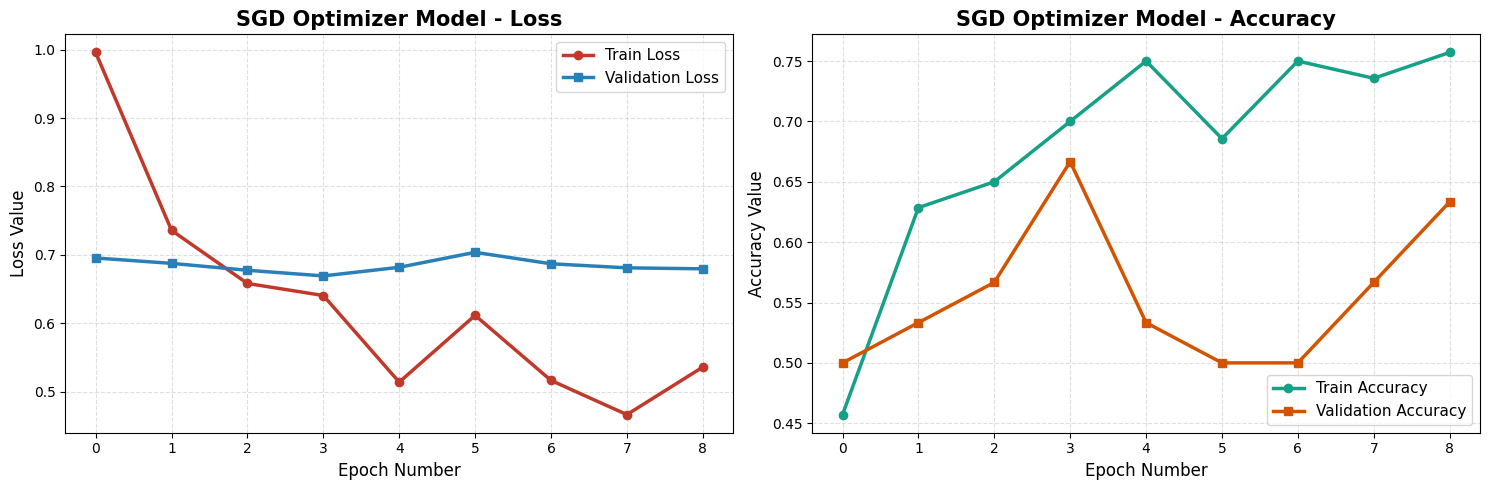

In [126]:
# Visualize SGD model training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1.plot(history_sgd.history['loss'], marker='o', label='Train Loss', linewidth=2.5, color='#c0392b')
ax1.plot(history_sgd.history['val_loss'], marker='s', label='Validation Loss', linewidth=2.5, color='#2980b9')
ax1.set_title('SGD Optimizer Model - Loss', fontsize=15, weight='bold')
ax1.set_xlabel('Epoch Number', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.4)

# Accuracy curves
ax2.plot(history_sgd.history['accuracy'], marker='o', label='Train Accuracy', linewidth=2.5, color='#16a085')
ax2.plot(history_sgd.history['val_accuracy'], marker='s', label='Validation Accuracy', linewidth=2.5, color='#d35400')
ax2.set_title('SGD Optimizer Model - Accuracy', fontsize=15, weight='bold')
ax2.set_xlabel('Epoch Number', fontsize=12)
ax2.set_ylabel('Accuracy Value', fontsize=12)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [127]:
# Evaluate SGD model
print("Evaluating SGD Optimizer Model...\n")

sgd_loss, sgd_acc = sgd_model.evaluate(test_images, test_labels, verbose=0)

print(f"SGD Optimizer Model Test Results:")
print(f"  Loss: {sgd_loss:.4f}")
print(f"  Accuracy: {sgd_acc:.4f} ({sgd_acc*100:.2f}%)")

# Predictions
sgd_predictions_prob = sgd_model.predict(test_images, verbose=0)
sgd_predictions = (sgd_predictions_prob > 0.5).astype('int32').reshape(-1)

# Report
print("\nClassification Metrics:")
print(classification_report(test_labels, sgd_predictions, 
                          target_names=['Green Light', 'Red Light'],
                          digits=4))

Evaluating SGD Optimizer Model...

SGD Optimizer Model Test Results:
  Loss: 0.6600
  Accuracy: 0.6667 (66.67%)

Classification Metrics:
              precision    recall  f1-score   support

 Green Light     0.6190    0.8667    0.7222        15
   Red Light     0.7778    0.4667    0.5833        15

    accuracy                         0.6667        30
   macro avg     0.6984    0.6667    0.6528        30
weighted avg     0.6984    0.6667    0.6528        30



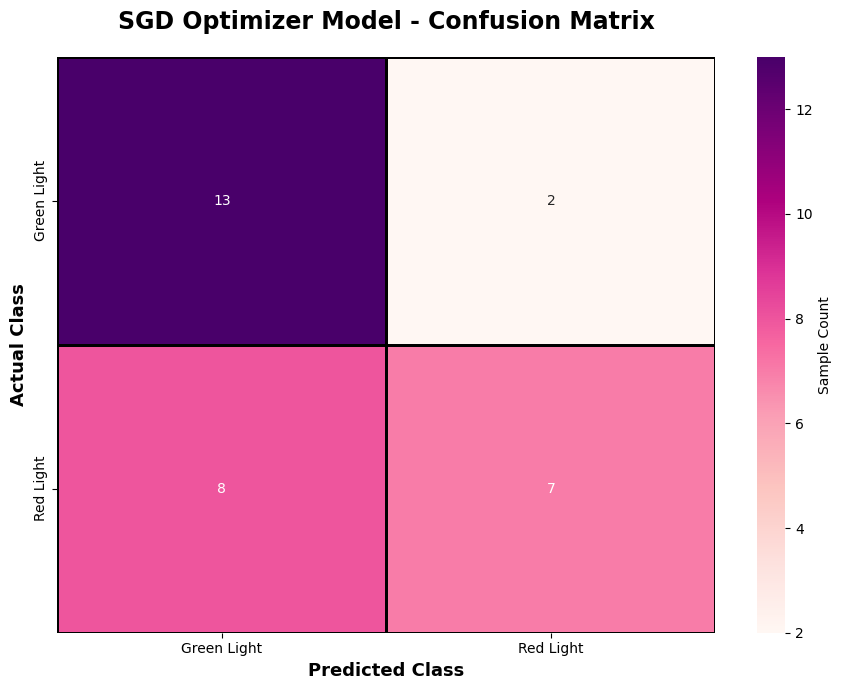

In [128]:
# Confusion matrix for SGD model
conf_matrix_sgd = confusion_matrix(test_labels, sgd_predictions)

plt.figure(figsize=(9, 7))
sns.heatmap(conf_matrix_sgd, 
            annot=True, 
            fmt='d', 
            cmap='RdPu', 
            xticklabels=['Green Light', 'Red Light'],
            yticklabels=['Green Light', 'Red Light'],
            cbar_kws={'label': 'Sample Count'},
            linewidths=1,
            linecolor='black')
plt.title('SGD Optimizer Model - Confusion Matrix', 
         fontsize=17, weight='bold', pad=20)
plt.xlabel('Predicted Class', fontsize=13, weight='bold')
plt.ylabel('Actual Class', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## Part 7: Comprehensive Model Comparison
Compare all three models to identify the best performing approach.

In [129]:
# Compile comparison metrics
model_names = [
    'Baseline CNN',
    'Enhanced (LR Scheduling)',
    'SGD + Momentum'
]

accuracies = [baseline_acc, lr_acc, sgd_acc]
losses = [baseline_loss, lr_loss, sgd_loss]

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': accuracies,
    'Test Loss': losses
})

print("\n" + "="*70)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


COMPREHENSIVE MODEL PERFORMANCE COMPARISON
                   Model  Test Accuracy  Test Loss
            Baseline CNN       0.866667   0.679916
Enhanced (LR Scheduling)       0.900000   0.324390
          SGD + Momentum       0.666667   0.660004


C:\Users\amare\AppData\Local\Temp\ipykernel_4280\1076541369.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(model_names, rotation=15, ha='right')
C:\Users\amare\AppData\Local\Temp\ipykernel_4280\1076541369.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(model_names, rotation=15, ha='right')


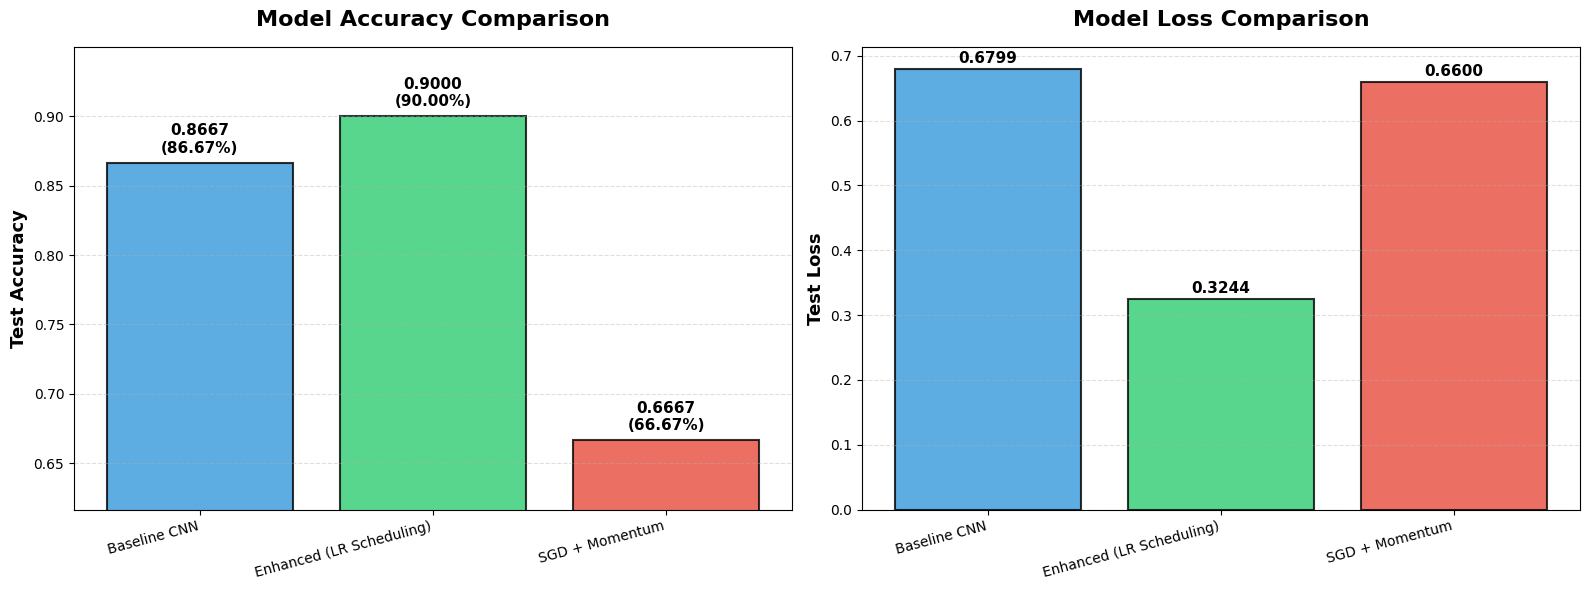

In [130]:
# Visual comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']

# Accuracy comparison
bars1 = ax1.bar(model_names, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Test Accuracy', fontsize=13, weight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=16, weight='bold', pad=15)
ax1.set_ylim([min(accuracies) - 0.05, max(accuracies) + 0.05])
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_xticklabels(model_names, rotation=15, ha='right')

for idx, (bar, val) in enumerate(zip(bars1, accuracies)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{val:.4f}\n({val*100:.2f}%)',
            ha='center', va='bottom', fontsize=11, weight='bold')

# Loss comparison
bars2 = ax2.bar(model_names, losses, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Test Loss', fontsize=13, weight='bold')
ax2.set_title('Model Loss Comparison', fontsize=16, weight='bold', pad=15)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_xticklabels(model_names, rotation=15, ha='right')

for idx, (bar, val) in enumerate(zip(bars2, losses)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

In [131]:
# Calculate improvements
print("\n" + "="*70)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("="*70)

lr_improvement = (lr_acc - baseline_acc) * 100
sgd_improvement = (sgd_acc - baseline_acc) * 100

print(f"\nBaseline CNN Performance:")
print(f"  Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"  Loss: {baseline_loss:.4f}")

print(f"\nEnhanced Model (Learning Rate Scheduling):")
print(f"  Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"  Loss: {lr_loss:.4f}")
print(f"  Improvement: {lr_improvement:+.2f}% accuracy")
print(f"  Loss Reduction: {baseline_loss - lr_loss:+.4f}")

print(f"\nSGD Optimizer Model (Momentum + Nesterov):")
print(f"  Accuracy: {sgd_acc:.4f} ({sgd_acc*100:.2f}%)")
print(f"  Loss: {sgd_loss:.4f}")
print(f"  Improvement: {sgd_improvement:+.2f}% accuracy")
print(f"  Loss Reduction: {baseline_loss - sgd_loss:+.4f}")

best_model_idx = np.argmax(accuracies)
print(f"\nBest Performing Model: {model_names[best_model_idx]}")
print(f"  Accuracy: {accuracies[best_model_idx]:.4f} ({accuracies[best_model_idx]*100:.2f}%)")
print("="*70)


PERFORMANCE IMPROVEMENT ANALYSIS

Baseline CNN Performance:
  Accuracy: 0.8667 (86.67%)
  Loss: 0.6799

Enhanced Model (Learning Rate Scheduling):
  Accuracy: 0.9000 (90.00%)
  Loss: 0.3244
  Improvement: +3.33% accuracy
  Loss Reduction: +0.3555

SGD Optimizer Model (Momentum + Nesterov):
  Accuracy: 0.6667 (66.67%)
  Loss: 0.6600
  Improvement: -20.00% accuracy
  Loss Reduction: +0.0199

Best Performing Model: Enhanced (LR Scheduling)
  Accuracy: 0.9000 (90.00%)
